In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Numerical parameters.
m = 1 # mass
g = 10 # gravity
r = .2 # length
I = .1 # moment of inertia
T = 2 # time horizon

In [2]:
# Helper funcion the computes derivative of order n.
def derivative(f, t, h=1e-4):
    return (f(t + h) - f(t)) / h
def derivative_order_n(f, t, n):
    if n == 1:
        return derivative(f, t)
    else:
        df = lambda t: derivative(f, t)
        return derivative_order_n(df, t, n - 1)

# Differential flatness.
def q3(t):
    ddq1 = derivative_order_n(q1, t, 2)
    ddq2 = derivative_order_n(q2, t, 2)
    return - np.arctan2(ddq1, ddq2 + g)
def u(t):
    ddq1 = derivative_order_n(q1, t, 2)
    ddq2 = derivative_order_n(q2, t, 2)
    ddq3 = derivative_order_n(q3, t, 2)
    a = m * np.sqrt(ddq1 ** 2 + (ddq2 + g) ** 2) / 2
    b = I * ddq3 / 2 / r
    return np.array([a - b, a + b])

### Control the trajectory

#### Solver for $\dot{q}_3 = \ddot{q}_3 = 0$ at initial and final state

In [56]:
def solver_2p_w_q3_0(x_0, y_0, x_T, y_T, T):
    x0, dx0 = x_0
    xT, dxT = x_T
    y0, dy0 = y_0
    yT, dyT = y_T

    A = np.array([
        [T**4,    T**5,    T**6,    T**7],
        [4*T**3,  5*T**4,  6*T**5,  7*T**6],
        [12*T**2, 20*T**3, 30*T**4, 42*T**5],
        [24*T,    60*T**2, 120*T**3, 210*T**4]
    ], dtype=float)

    B = np.array([
        xT - x0 - dx0*T,
        dxT - dx0,
        0.0,
        0.0
    ], dtype=float)

    X = np.linalg.solve(A, B)

    a4, a5, a6, a7 = X
    a0 = x0
    a1 = dx0
    a2 = 0.0
    a3 = 0.0

    coeffs_a = np.array([a7, a6, a5, a4, a3, a2, a1, a0])
    #print(coeffs)

    C = np.array([
        [T**2,   T**3],
        [2*T,   3*T**2]
    ], dtype=float)

    D = np.array([
        yT - y0 - dy0*T,
        dyT - dy0
    ], dtype=float)

    Y = np.linalg.solve(C, D)

    b2, b3 = Y
    b0 = y0
    b1 = dy0

    coeffs_b = np.array([b3, b2, b1, b0])
    return coeffs_a, coeffs_b

A, B = solver_2p_w_q3_0([1,0], [3,0], [4,0], [2,0], 2)

In [53]:
print(A, B)

[-0.3125  2.1875 -5.25    4.375   0.      0.      0.      2.    ] [0. 0. 0. 2.]


In [57]:
# Center of mass trajectory
def q2(t, A = [-0.25, 0.75, 0, 0]):
    
    q = np.array(A) @ np.array([t**3, t**2, t, 1]).T
    return q ### YOUR CODE HERE

def q1(t, A = [-0.15625, 1.09375, -2.625, 2.1875, 0,  0, 0, 0]):
    q = np.array(A) @ np.array([t**7, t**6, t**5, t**4, t**3, t**2, t, 1]).T
    return q

### Plot quadrotor snapshots.

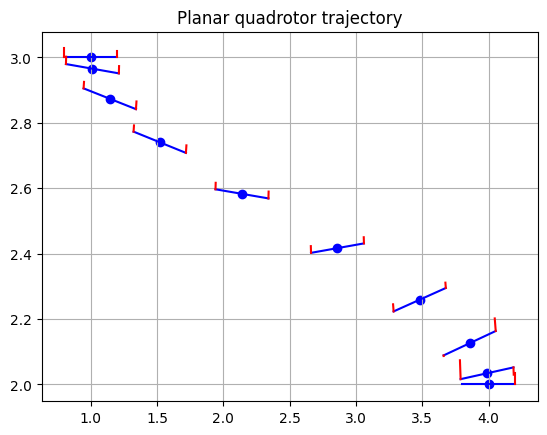

In [58]:
# Plot quadrotor snapshots.
plt.figure()
snapshots = 10
times = np.linspace(0, T, snapshots)
for t in times:
    q1t = q1(t, A)
    q2t = q2(t, B)
    q3t = q3(t)

    # Quadrotor body.
    c3t = np.cos(q3t)
    s3t = np.sin(q3t)
    endpoints = np.array([
        [q1t - r * c3t, q2t - r * s3t],
        [q1t + r * c3t, q2t + r * s3t]])
    plt.scatter(q1t, q2t, c='b')
    plt.plot(*endpoints.T, c='b')

    # Rotor thrusts as red segments.
    d = endpoints[1] - endpoints[0]
    v = np.array([-d[1], d[0]]) / 100
    for ui, ei in zip(u(t), endpoints):
        force = np.array([ei, ei + v * ui])
        plt.plot(*force.T, c='r')

# Plot options.
plt.title('Planar quadrotor trajectory')
plt.grid()